## Importing libraries and plot styling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#0d1117',
    'savefig.facecolor': '#0d1117',
    'axes.edgecolor': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'grid.color': '#30363d',
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

PLASMA = sns.color_palette('plasma', 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## Loading data and mapping questions to short indicator codes

In [2]:
df = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\Nutrition_Physical_Activity_Obesity_Clean.csv", low_memory=False)

question_map = {
    'Percent of adults aged 18 years and older who have obesity': 'OBESITY',
    'Percent of adults aged 18 years and older who have an overweight classification': 'OVERWEIGHT',
    'Percent of adults who engage in no leisure-time physical activity': 'INACTIVE',
    'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)': 'MEETS_AEROBIC',
    'Percent of adults who achieve at least 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)': 'MEETS_AEROBIC_300',
    'Percent of adults who engage in muscle-strengthening activities on 2 or more days a week': 'MEETS_STRENGTH',
    'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity and engage in muscle-strengthening activities on 2 or more days a week': 'MEETS_BOTH',
    'Percent of adults who report consuming fruit less than one time daily': 'LOW_FRUIT',
    'Percent of adults who report consuming vegetables less than one time daily': 'LOW_VEG',
}

df['Indicator'] = df['Question'].map(question_map)
assert df['Indicator'].isna().sum() == 0, 'Unmapped question found'

print('Rows:', len(df))
print('Years:', sorted(df['YearStart'].unique()))
print('Indicators:', sorted(df['Indicator'].unique()))
print()
print('Rows per indicator per year (Total stratification):')
tot_check = df[df['StratificationCategory1'] == 'Total']
print(tot_check.pivot_table(index='YearStart', columns='Indicator', values='Data_Value', aggfunc='count'))

Rows: 106260
Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Indicators: ['INACTIVE', 'LOW_FRUIT', 'LOW_VEG', 'MEETS_AEROBIC', 'MEETS_AEROBIC_300', 'MEETS_BOTH', 'MEETS_STRENGTH', 'OBESITY', 'OVERWEIGHT']

Rows per indicator per year (Total stratification):
Indicator  INACTIVE  LOW_FRUIT  LOW_VEG  MEETS_AEROBIC  MEETS_AEROBIC_300  MEETS_BOTH  MEETS_STRENGTH  OBESITY  OVERWEIGHT
YearStart                                                                                                                 
2011           55.0        NaN      NaN           55.0               55.0        55.0            55.0     55.0        55.0
2012           55.0        NaN      NaN            NaN                NaN         NaN             NaN     55.0        55.0
2013           55.0        NaN      NaN           55.0               55.0        5

In [3]:
territories = ['GU', 'PR', 'VI']   # drop non-state territories; keep DC as a state-equivalent unit
df_states = df[~df['LocationAbbr'].isin(territories)].copy()

keep_cols = ['YearStart', 'LocationAbbr', 'LocationDesc', 'Indicator', 'Data_Value',
             'Low_Confidence_Limit', 'High_Confidence_Limit ', 'Sample_Size',
             'StratificationCategory1', 'Stratification1']

core = df_states[keep_cols].rename(columns={
    'YearStart': 'Year',
    'High_Confidence_Limit ': 'High_CL',
    'Low_Confidence_Limit': 'Low_CL',
})

print(core.shape)
core.head()

(100464, 10)


,Year,LocationAbbr,LocationDesc,Indicator,Data_Value,Low_CL,High_CL,Sample_Size,StratificationCategory1,Stratification1
0,2011,AL,Alabama,OBESITY,34.8,31.3,38.5,1367.0,Income,"$15,000 - $24,999"
1,2011,AL,Alabama,OBESITY,35.8,31.1,40.8,757.0,Income,"$25,000 - $34,999"
2,2011,AL,Alabama,OBESITY,32.3,28.0,36.8,861.0,Income,"$35,000 - $49,999"
3,2011,AL,Alabama,OBESITY,34.1,29.7,38.8,785.0,Income,"$50,000 - $74,999"
4,2011,AL,Alabama,OBESITY,28.8,25.4,32.5,1125.0,Income,"$75,000 or greater"


## Tier 1: full-span trend, 2011–2023
## State-year panel: obesity, overweight, inactivity (annual)

In [4]:
tier1_long = core[(core['StratificationCategory1'] == 'Total') &
                   (core['Indicator'].isin(['OBESITY', 'OVERWEIGHT', 'INACTIVE'])) &
                   (core['LocationAbbr'] != 'US')].copy()

tier1 = tier1_long.pivot_table(index=['Year', 'LocationAbbr', 'LocationDesc'],
                                columns='Indicator', values='Data_Value').reset_index()
tier1.columns.name = None

print(tier1.shape)          # expect 51 states/DC x 13 years = 663 rows
print(tier1.isna().sum())
tier1.head()

(663, 6)
Year            0
LocationAbbr    0
LocationDesc    0
INACTIVE        0
OBESITY         0
OVERWEIGHT      0
dtype: int64


,Year,LocationAbbr,LocationDesc,INACTIVE,OBESITY,OVERWEIGHT
0,2011,AK,Alaska,22.0,27.4,38.9
1,2011,AL,Alabama,32.6,32.0,34.7
2,2011,AR,Arkansas,30.9,30.9,33.9
3,2011,AZ,Arizona,24.1,25.1,37.8
4,2011,CA,California,19.1,23.8,36.4


## National trend, 2011–2023

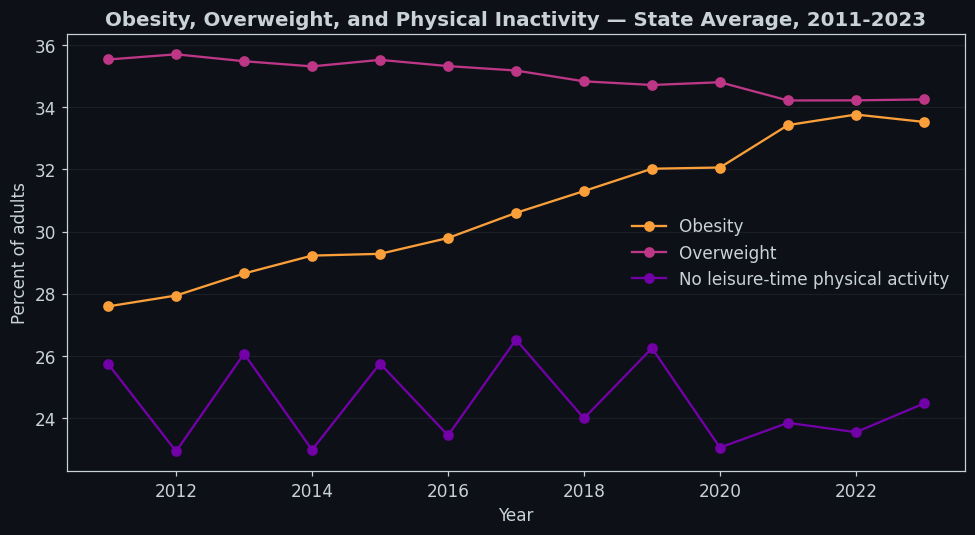

      OBESITY  OVERWEIGHT  INACTIVE
Year                               
2011    27.59       35.53     25.74
2012    27.94       35.70     22.93
2013    28.65       35.48     26.07
2014    29.23       35.31     22.98
2015    29.28       35.52     25.75
2016    29.79       35.32     23.44
2017    30.60       35.18     26.52
2018    31.30       34.83     23.99
2019    32.02       34.71     26.25
2020    32.06       34.80     23.05
2021    33.42       34.22     23.85
2022    33.76       34.22     23.55
2023    33.53       34.25     24.47


In [5]:
national = tier1.groupby('Year')[['OBESITY', 'OVERWEIGHT', 'INACTIVE']].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(national.index, national['OBESITY'], marker='o', color=PLASMA[6], label='Obesity')
ax.plot(national.index, national['OVERWEIGHT'], marker='o', color=PLASMA[3], label='Overweight')
ax.plot(national.index, national['INACTIVE'], marker='o', color=PLASMA[1], label='No leisure-time physical activity')
ax.set_title('Obesity, Overweight, and Physical Inactivity — State Average, 2011-2023')
ax.set_ylabel('Percent of adults')
ax.set_xlabel('Year')
ax.legend(frameon=False)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(national.round(2))

## Which states changed the most, 2011 vs 2023

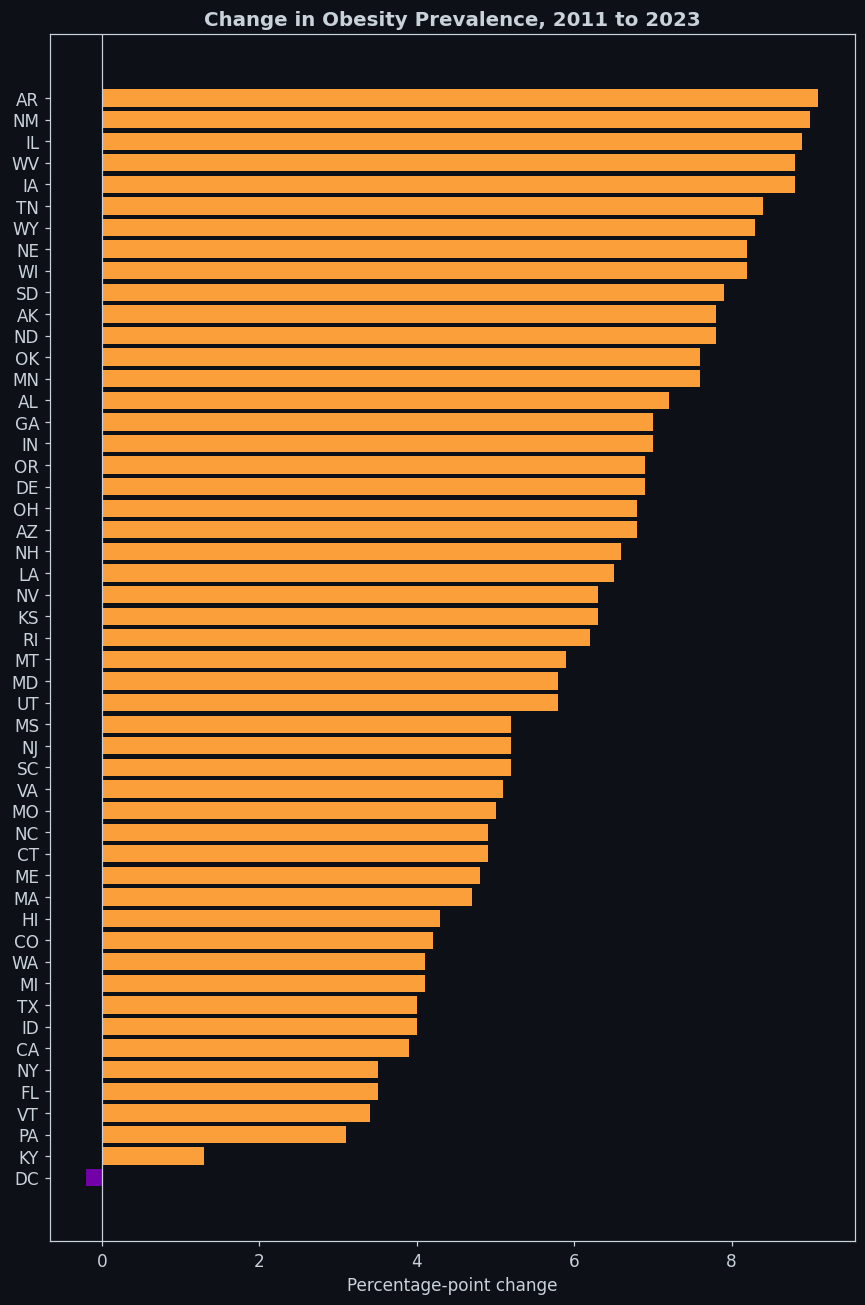

Largest increases:
Year          delta
LocationAbbr       
AR              9.1
NM              9.0
IL              8.9
WV              8.8
IA              8.8
Smallest increases / decreases:
Year          delta
LocationAbbr       
DC             -0.2
KY              1.3
PA              3.1
VT              3.4
FL              3.5


In [6]:
first_year, last_year = tier1['Year'].min(), tier1['Year'].max()
change = tier1[tier1['Year'].isin([first_year, last_year])].pivot(
    index='LocationAbbr', columns='Year', values='OBESITY')
change['delta'] = change[last_year] - change[first_year]
change = change.sort_values('delta')

fig, ax = plt.subplots(figsize=(8, 12))
colors = [PLASMA[6] if v > 0 else PLASMA[1] for v in change['delta']]
ax.barh(change.index, change['delta'], color=colors)
ax.axvline(0, color='#c9d1d9', linewidth=0.8)
ax.set_title(f'Change in Obesity Prevalence, {first_year} to {last_year}')
ax.set_xlabel('Percentage-point change')
plt.tight_layout()
plt.show()

print('Largest increases:')
print(change.sort_values('delta', ascending=False).head(5)[['delta']])
print('Smallest increases / decreases:')
print(change.head(5)[['delta']])

## Ecological (between-state) vs within-state association: inactivity and obesity

In [7]:
tier1['Year_c'] = tier1['Year'] - tier1['Year'].mean()

# Pooled cross-sectional model: does a state with higher inactivity also have higher obesity?
pooled = smf.ols('OBESITY ~ INACTIVE + Year_c', data=tier1).fit(
    cov_type='cluster', cov_kwds={'groups': tier1['LocationAbbr']})

# State fixed-effects model: within the same state, does obesity move with inactivity over time?
fe = smf.ols('OBESITY ~ INACTIVE + Year_c + C(LocationAbbr)', data=tier1).fit(
    cov_type='cluster', cov_kwds={'groups': tier1['LocationAbbr']})

print('POOLED (between-state) model')
print(f"  INACTIVE coef = {pooled.params['INACTIVE']:.3f}, p = {pooled.pvalues['INACTIVE']:.4g}, R2 = {pooled.rsquared:.3f}")
print()
print('STATE FIXED-EFFECTS (within-state) model')
print(f"  INACTIVE coef = {fe.params['INACTIVE']:.3f}, p = {fe.pvalues['INACTIVE']:.4g}")
print(f"  Year_c coef    = {fe.params['Year_c']:.3f}, p = {fe.pvalues['Year_c']:.4g}")

POOLED (between-state) model
  INACTIVE coef = 0.616, p = 8.773e-24, R2 = 0.595

STATE FIXED-EFFECTS (within-state) model
  INACTIVE coef = -0.003, p = 0.8898
  Year_c coef    = 0.545, p = 7.748e-177


states with more inactivity also tend to have higher obesity (pooled coefficient ≈ 0.62, p < .001), but within a given state, year-to-year changes in obesity are not well explained by year-to-year changes in inactivity once you control for the state's baseline level — obesity has climbed steadily across almost every state regardless of local inactivity fluctuations.

## Subgroup trends: age, sex, income, education, race

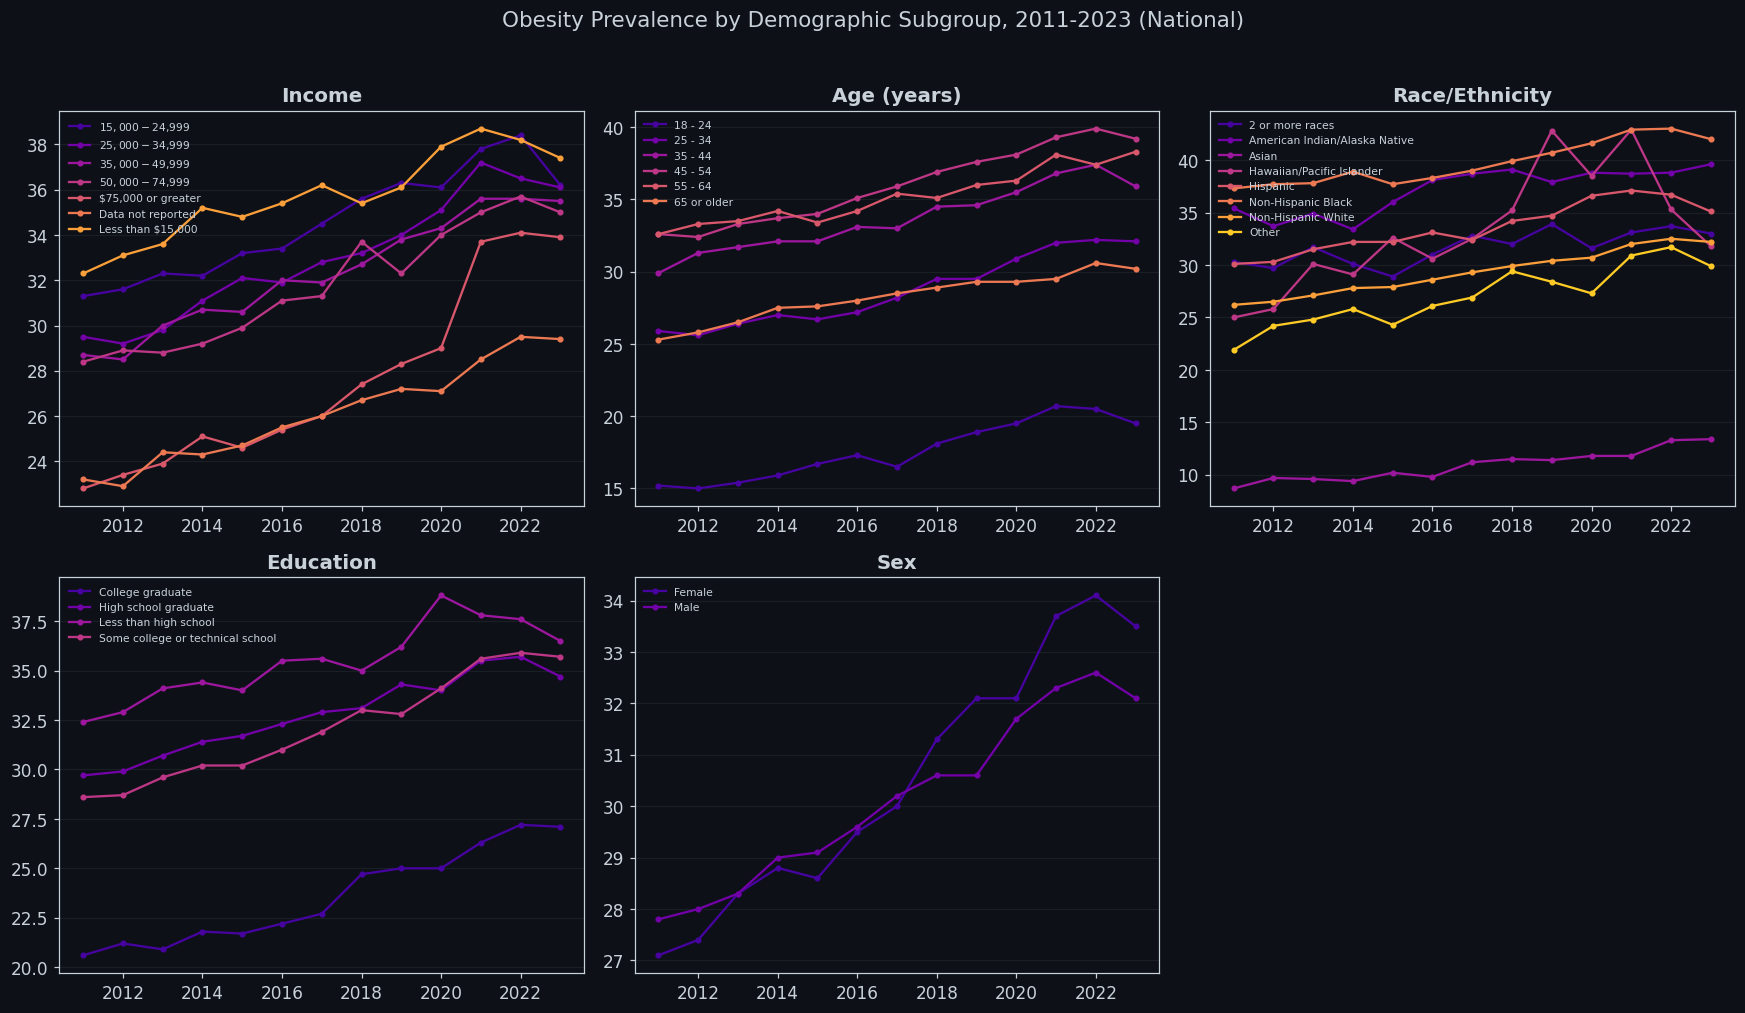

In [8]:
nat_sub = core[(core['LocationAbbr'] == 'US') &
               (core['StratificationCategory1'].isin(['Age (years)', 'Sex', 'Income', 'Education', 'Race/Ethnicity'])) &
               (core['Indicator'] == 'OBESITY')].copy()

categories = nat_sub['StratificationCategory1'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = nat_sub[nat_sub['StratificationCategory1'] == cat]
    ax = axes[i]
    for j, grp in enumerate(sorted(sub['Stratification1'].unique())):
        g = sub[sub['Stratification1'] == grp].sort_values('Year')
        ax.plot(g['Year'], g['Data_Value'], marker='o', markersize=3,
                color=PLASMA[j % len(PLASMA)], label=grp, linewidth=1.5)
    ax.set_title(cat)
    ax.legend(fontsize=7, frameon=False, loc='upper left')
    ax.grid(axis='y')

for k in range(len(categories), len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Obesity Prevalence by Demographic Subgroup, 2011-2023 (National)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Tier 2: multi-behavior lifestyle profiles, 2017 & 2019
## Building the multi-indicator state-year table

In [9]:
tier2_indicators = ['INACTIVE', 'MEETS_AEROBIC', 'MEETS_STRENGTH', 'LOW_FRUIT', 'LOW_VEG']

tier2_long = core[(core['StratificationCategory1'] == 'Total') &
                   (core['Year'].isin([2017, 2019])) &
                   (core['Indicator'].isin(tier2_indicators + ['OBESITY', 'OVERWEIGHT'])) &
                   (core['LocationAbbr'] != 'US')].copy()

tier2 = tier2_long.pivot_table(index=['Year', 'LocationAbbr', 'LocationDesc'],
                                columns='Indicator', values='Data_Value').reset_index()
tier2.columns.name = None

print(tier2.shape)   # expect 51 x 2 = 102 rows
print(tier2.isna().sum())
tier2.head()

(102, 10)
Year              0
LocationAbbr      0
LocationDesc      0
INACTIVE          0
LOW_FRUIT         0
LOW_VEG           0
MEETS_AEROBIC     0
MEETS_STRENGTH    0
OBESITY           0
OVERWEIGHT        0
dtype: int64


,Year,LocationAbbr,LocationDesc,INACTIVE,LOW_FRUIT,LOW_VEG,MEETS_AEROBIC,MEETS_STRENGTH,OBESITY,OVERWEIGHT
0,2017,AK,Alaska,20.6,36.9,19.0,58.3,34.7,34.2,32.6
1,2017,AL,Alabama,32.0,44.9,19.3,42.8,26.0,36.3,33.9
2,2017,AR,Arkansas,32.5,44.7,19.3,45.4,25.6,35.0,35.4
3,2017,AZ,Arizona,25.1,37.2,20.8,52.7,31.5,29.5,35.3
4,2017,CA,California,20.0,32.5,21.4,57.5,34.3,25.1,35.8


## Choosing the number of profiles (elbow and silhouette)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

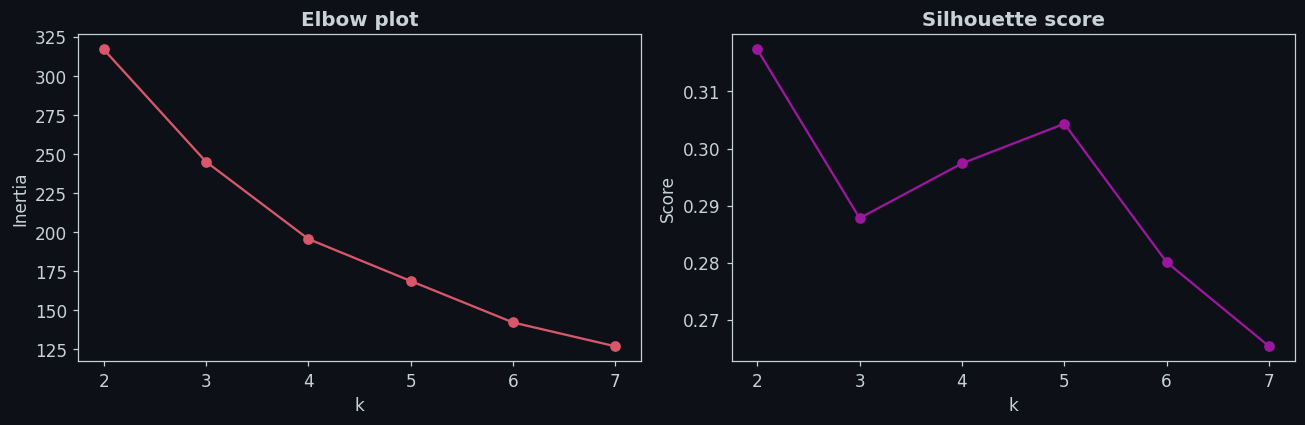

2 0.3174
3 0.2878
4 0.2974
5 0.3043
6 0.2801
7 0.2653


In [10]:
behavior_cols = ['INACTIVE', 'MEETS_AEROBIC', 'MEETS_STRENGTH', 'LOW_FRUIT', 'LOW_VEG']
X = tier2[behavior_cols].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

inertia, sil = {}, {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    inertia[k] = km.inertia_
    sil[k] = silhouette_score(Xs, labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(inertia.keys()), list(inertia.values()), marker='o', color=PLASMA[4])
axes[0].set_title('Elbow plot')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(sil.keys()), list(sil.values()), marker='o', color=PLASMA[2])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

for k in sil:
    print(k, round(sil[k], 4))

*k=2* gives the cleanest statistical split, but the conceptual framework we are testing calls for four profiles (active+healthy, inactive+poor diet, and two mixed-risk types), and *k=4* is close behind on silhouette score while being far more informative substantively. *k=4* is used below

## Fit k=4 clustering and build data-driven profile labels

In [11]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=50)
tier2['cluster'] = km.fit_predict(Xs)

centers = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=behavior_cols)
centers.index.name = 'cluster'

# Composite risk score per cluster: inactivity/low fruit/low veg raise risk,
# meeting aerobic/strength guidelines lowers it. Purely data-driven ranking, no manual labeling.
risk_direction = {'INACTIVE': 1, 'MEETS_AEROBIC': -1, 'MEETS_STRENGTH': -1, 'LOW_FRUIT': 1, 'LOW_VEG': 1}
z = (centers - centers.mean()) / centers.std()
risk_score = sum(z[c] * d for c, d in risk_direction.items())

order = risk_score.sort_values().index.tolist()
label_names = ['Active + Healthier Diet (low risk)',
               'Mixed risk - moderate activity',
               'Mixed risk - low activity emphasis',
               'Inactive + Poor Diet (high risk)']
label_map = dict(zip(order, label_names))

tier2['profile'] = tier2['cluster'].map(label_map)
centers_labeled = centers.rename(index=label_map)

print(centers_labeled.round(1))
print()
print(tier2.groupby('profile')['OBESITY'].agg(['mean', 'count']).sort_values('mean'))

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                                    INACTIVE  MEETS_AEROBIC  MEETS_STRENGTH  LOW_FRUIT  LOW_VEG
cluster                                                                                        
Mixed risk - moderate activity          26.7           50.2            30.5       35.4     17.1
Mixed risk - low activity emphasis      26.0           51.5            35.7       39.7     21.1
Inactive + Poor Diet (high risk)        32.4           43.3            27.9       44.2     21.2
Active + Healthier Diet (low risk)      20.7           57.9            35.6       34.6     17.7

                                         mean  count
profile                                             
Active + Healthier Diet (low risk)  28.073684     19
Mixed risk - moderate activity      30.350000     34
Mixed risk - low activity emphasis  31.558065     31
Inactive + Poor Diet (high risk)    36.111111     18


## Profile characterization heatmap

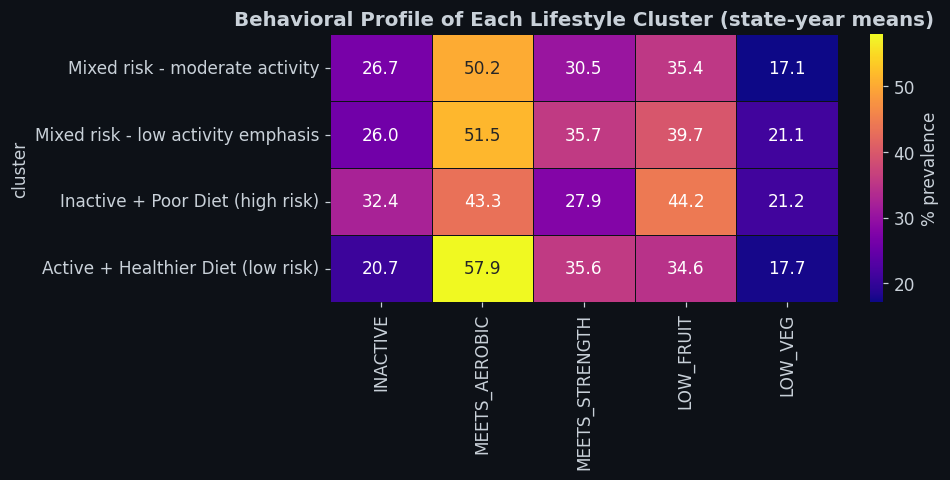

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(centers_labeled, annot=True, fmt='.1f', cmap='plasma',
            cbar_kws={'label': '% prevalence'}, linewidths=0.5, linecolor='#0d1117', ax=ax)
ax.set_title('Behavioral Profile of Each Lifestyle Cluster (state-year means)')
plt.tight_layout()
plt.show()

## Profile prevalence, 2017 vs 2019, and transition matrix

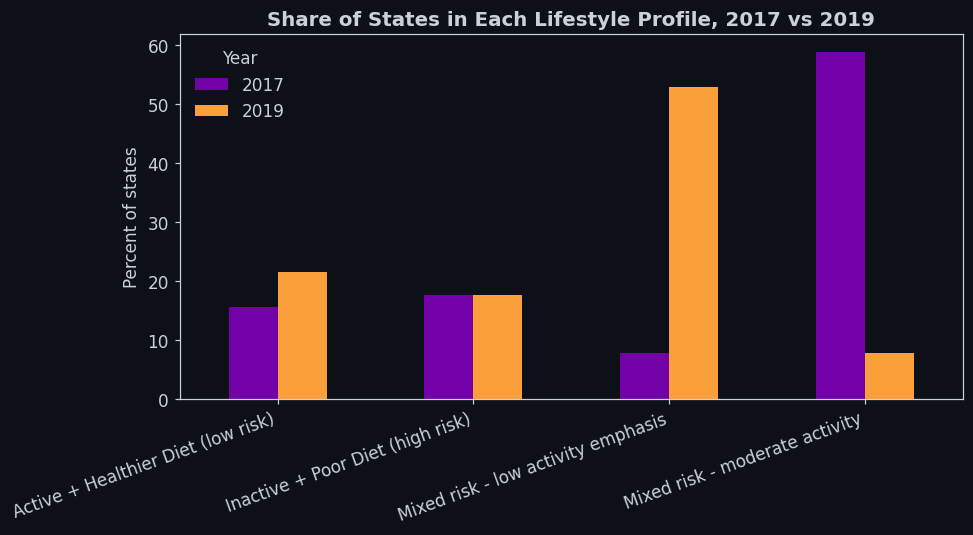

profile  Active + Healthier Diet (low risk)  Inactive + Poor Diet (high risk)  Mixed risk - low activity emphasis  Mixed risk - moderate activity
Year                                                                                                                                             
2017                                   15.7                              17.6                                 7.8                            58.8
2019                                   21.6                              17.6                                52.9                             7.8

Chi-square test of profile distribution shift: chi2 = 37.42, p = 3.749e-08

State-level transition matrix (2017 profile -> 2019 profile):
2019                                Active + Healthier Diet (low risk)  Inactive + Poor Diet (high risk)  Mixed risk - low activity emphasis  \
2017                                                                                                                                 

In [13]:
prevalence = tier2.groupby(['Year', 'profile']).size().unstack(fill_value=0)
prevalence_pct = prevalence.div(prevalence.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
prevalence_pct.T.plot(kind='bar', ax=ax, color=[PLASMA[1], PLASMA[6]])
ax.set_title('Share of States in Each Lifestyle Profile, 2017 vs 2019')
ax.set_ylabel('Percent of states')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
ax.legend(title='Year', frameon=False)
plt.tight_layout()
plt.show()

print(prevalence_pct.round(1))
print()

chi2, p, dof, exp = chi2_contingency(pd.crosstab(tier2['Year'], tier2['profile']))
print(f'Chi-square test of profile distribution shift: chi2 = {chi2:.2f}, p = {p:.4g}')
print()

state_transitions = tier2.pivot(index='LocationAbbr', columns='Year', values='profile')
transition_matrix = pd.crosstab(state_transitions[2017], state_transitions[2019])
print('State-level transition matrix (2017 profile -> 2019 profile):')
print(transition_matrix)

## Association between lifestyle profile and obesity

In [14]:
profile_reg = smf.ols(
    'OBESITY ~ C(profile, Treatment(reference="Active + Healthier Diet (low risk)")) + C(Year)',
    data=tier2
).fit()

print(profile_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                OBESITY   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     18.80
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.80e-11
Time:                        17:27:16   Log-Likelihood:                -255.07
No. Observations:                 102   AIC:                             520.1
Df Residuals:                      97   BIC:                             533.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

## Does the profile-obesity association hold across age, sex, and income?

In [15]:
profile_lookup = tier2.set_index(['Year', 'LocationAbbr'])['profile'].to_dict()

sub_ob = core[(core['Year'].isin([2017, 2019])) &
              (core['Indicator'] == 'OBESITY') &
              (core['StratificationCategory1'].isin(['Age (years)', 'Sex', 'Income'])) &
              (core['LocationAbbr'] != 'US')].copy()

sub_ob['profile'] = sub_ob.apply(lambda r: profile_lookup.get((r['Year'], r['LocationAbbr'])), axis=1)
sub_ob = sub_ob.dropna(subset=['profile'])

for category in ['Sex', 'Age (years)', 'Income']:
    print(f'=== Moderation by {category} ===')
    d = sub_ob[sub_ob['StratificationCategory1'] == category]
    m = smf.ols(
        'Data_Value ~ C(profile, Treatment(reference="Active + Healthier Diet (low risk)")) * C(Stratification1) + C(Year)',
        data=d
    ).fit()
    interaction_terms = [p for p in m.pvalues.index if ':' in p]
    sig = m.pvalues[interaction_terms]
    print(f'  {sum(sig < 0.05)} of {len(sig)} interaction terms significant at p<0.05')
    print(f'  Base model R2 = {m.rsquared:.3f}')
    print()

=== Moderation by Sex ===
  0 of 3 interaction terms significant at p<0.05
  Base model R2 = 0.390

=== Moderation by Age (years) ===
  2 of 15 interaction terms significant at p<0.05
  Base model R2 = 0.772

=== Moderation by Income ===
  0 of 18 interaction terms significant at p<0.05
  Base model R2 = 0.527



## Synthesis figure: profile shift set against the long-run trend

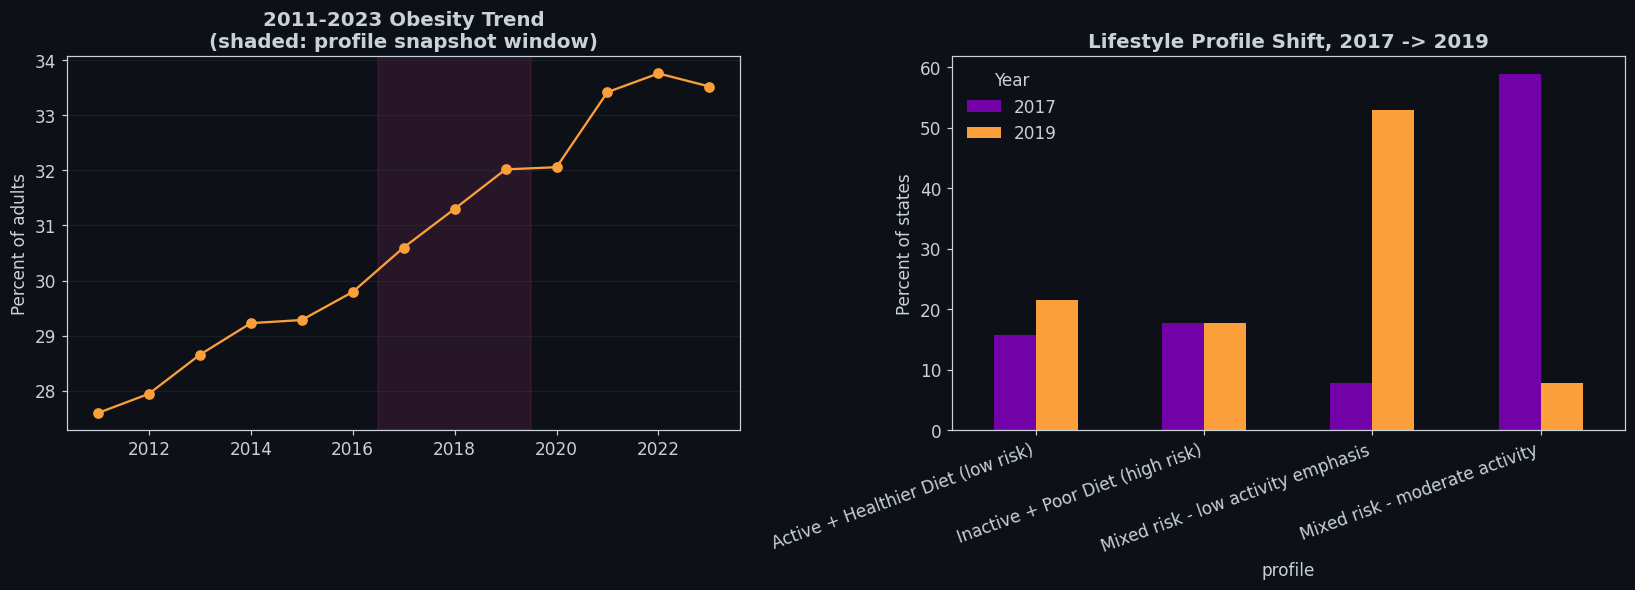

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(national.index, national['OBESITY'], marker='o', color=PLASMA[6])
axes[0].axvspan(2016.5, 2019.5, color=PLASMA[3], alpha=0.15)
axes[0].set_title('2011-2023 Obesity Trend\n(shaded: profile snapshot window)')
axes[0].set_ylabel('Percent of adults')
axes[0].grid(axis='y')

prevalence_pct.T.plot(kind='bar', ax=axes[1], color=[PLASMA[1], PLASMA[6]])
axes[1].set_title('Lifestyle Profile Shift, 2017 -> 2019')
axes[1].set_ylabel('Percent of states')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(title='Year', frameon=False)

plt.tight_layout()
plt.show()

## Exporting tables for the project appendix

In [17]:
tier1.to_csv('tier1_state_year_trend_2011_2023.csv', index=False)
tier2.to_csv('tier2_lifestyle_profiles_2017_2019.csv', index=False)
centers_labeled.to_csv('tier2_cluster_centers.csv')
transition_matrix.to_csv('tier2_state_transition_matrix.csv')

print('Exported: tier1_state_year_trend_2011_2023.csv')
print('Exported: tier2_lifestyle_profiles_2017_2019.csv')
print('Exported: tier2_cluster_centers.csv')
print('Exported: tier2_state_transition_matrix.csv')

Exported: tier1_state_year_trend_2011_2023.csv
Exported: tier2_lifestyle_profiles_2017_2019.csv
Exported: tier2_cluster_centers.csv
Exported: tier2_state_transition_matrix.csv


## Methodologically Note that;
1. The unit of clustering is the state-year, not the individual, because this is an ecological design.
   